# The Berry curvature, a Chern number and a Z2 invariant

The Berry curvature is the field strength of the geometric connection an occupied band
carries around the Brillouin zone, and its integral over a closed zone is an integer:

$$\Omega_{n}(\mathbf k) = i\,\nabla_{\mathbf k} \times
   \langle u_{n\mathbf k}|\nabla_{\mathbf k} u_{n\mathbf k}\rangle,
\qquad
C = \frac{1}{2\pi}\int_{\rm BZ} \Omega(\mathbf k)\; d^2k \in \mathbb{Z}$$

Two different things are wanted from it. The **integer** is what quantises a quantum Hall
conductance and what separates a topological insulator from an ordinary one: no continuous
deformation of the Hamiltonian can change it without closing the gap. The **map** is where
in the zone the curvature lives, which is what an anomalous-Hall or a valley-Hall argument
is made of.

| | | |
|---|---|---|
| AlAs, $\max|\Omega|$ on a $24\times24$ mesh | **1.3605** | time reversal, no inversion centre |
| AlAs, Chern number | **1.8e-16** | zero, and exactly so |
| silicon, $\max|\Omega|$ | **8.7e-08** | inversion *and* time reversal: zero pointwise |
| Haldane model, $C$ on a $6\times6$ mesh | **-1.000000000000000** | $|C| = 1$, the sign following $\phi$ |
| Kane-Mele model, $\nu$ | **1** below the critical mass, **0** above | the transition is at $3\sqrt3\,\lambda_{\rm SO}$ |

AlAs is the crystal to see the map on: it has time-reversal symmetry but no inversion
centre, so $\Omega(\mathbf k)$ is nonzero point by point while the integer over the zone is
zero. Silicon has both symmetries, which forces the curvature to vanish *pointwise* -- a
stronger statement than the integer being zero, and the one that says the map is being
computed rather than the sum.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from defumat import Calculator

CASES, PSEUDO = Path("../tests/data/qe"), Path("../tests/data/pseudo")

alas = Calculator.from_file(CASES / "alas-raman.in", pseudo_dir=PSEUDO, announce=False)
omega = alas.get_berry_curvature(shape=(24, 24), nbnd=20, method="kubo")
print("AlAs   max|Omega| = %.4f     sum over empty states truncated by %.1f %%"
      % (np.abs(omega.curvature).max(), 100 * omega.truncation))

AlAs   max|Omega| = 1.3605     sum over empty states truncated by 2.0 %


The curvature is built from the velocity operator,

$$\Omega_n^{12}(\mathbf k) = -2\,\mathrm{Im} \sum_{m \neq n}
\frac{A^{1}_{nm} A^{2}_{mn}}{(\varepsilon_n - \varepsilon_m)^2},
\qquad A^{a}_{nm} = \langle \psi_n |\, \partial_{k_a} H
   - \varepsilon_n \partial_{k_a} S \,| \psi_m \rangle ,$$

which is a sum over the empty bands, so it is truncated and the truncation is reported
rather than tuned away: raising the band count is what tightens it. The overlap operator
carries $\mathbf k$ as well, which is why $\partial_k S$ is there beside $\partial_k H$.

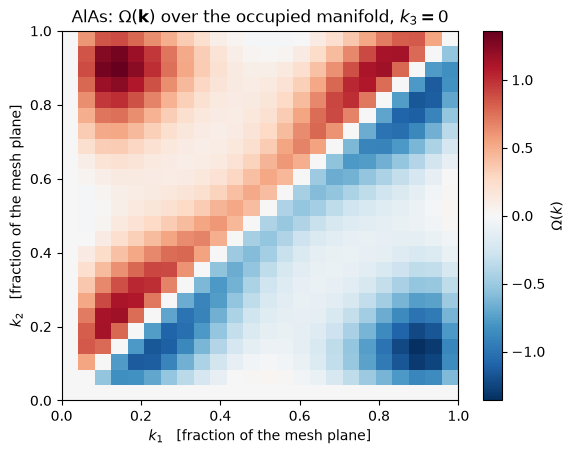

In [2]:
ax = omega.plot()
ax.set_title(r"AlAs: $\Omega(\mathbf{k})$ over the occupied manifold, $k_3 = 0$")
ax.grid(False)

The map is **odd** under $\mathbf k \to -\mathbf k$: every red lobe has a blue one opposite
it through the centre. That is time-reversal symmetry with no inversion centre to go with
it, and it is why the integral over the zone can vanish while the map itself is of order
one. The pale diagonal is the mirror plane zincblende has along $k_1 = k_2$, on which the
curvature is pinned to zero.

## The integer wants a different construction

Summing that map over a mesh is an ordinary Riemann sum, and a Riemann sum of a smooth
function is not an integer. What is an integer on *any* mesh is the lattice form of Fukui,
Hatsugai and Suzuki: the phase of a product of overlap determinants around each plaquette,

$$C = \frac{1}{2\pi}\sum_{\square}
  \arg \Big[
   \det M^{(\mathbf k,\mathbf k+\mathbf b_1)}\;
   \det M^{(\mathbf k+\mathbf b_1,\mathbf k+\mathbf b_1+\mathbf b_2)}\;
   \det M^{(\cdots)}\;\det M^{(\cdots)} \Big],
\qquad
M^{(\mathbf k,\mathbf k')}_{mn} = \langle u_{m\mathbf k}|\hat S|u_{n\mathbf k'}\rangle$$

each phase taken in $(-\pi,\pi]$. A determinant of overlaps is blind to however the
eigensolver mixed a degenerate multiplet, and the sum of the phases cannot be anything but
a multiple of $2\pi$. It is the default here, and the Kubo map above is the alternative.

In [3]:
silicon = Calculator.from_file(CASES / "si-epsilon.in", pseudo_dir=PSEUDO, announce=False)
si = silicon.get_berry_curvature(shape=(8, 8), nbnd=16, method="kubo")

print("AlAs     Chern number, lattice flux   %9.2e   <- an integer by construction"
      % alas.get_chern(shape=(24, 24)))
print("         the same map, Riemann sum    %9.2e   <- near zero, and not zero"
      % omega.chern_number)
print("silicon  max|Omega|, pointwise        %9.2e   <- inversion and time reversal"
      % np.abs(si.curvature).max())

AlAs     Chern number, lattice flux    1.83e-16   <- an integer by construction
         the same map, Riemann sum     1.99e-06   <- near zero, and not zero
silicon  max|Omega|, pointwise         8.71e-08   <- inversion and time reversal


## Where the invariant is not zero

No crystal above has one, because a nonzero Chern number needs time-reversal symmetry
broken and a nonzero $\mathbb{Z}_2$ needs it unbroken together with strong spin-orbit
coupling. The two models that defined those phases are the cheapest place to see both.
Haldane's honeycomb model has a complex second-neighbour hopping that breaks time reversal
without a net field; Kane and Mele's is two time-reversed Haldane copies, one per spin,
which restores it and leaves a $\mathbb{Z}_2$ behind.

In [4]:
import sys; sys.path.insert(0, "..")
from tests.models import haldane, kane_mele, kane_mele_critical_mass
from defumat.topology import ModelSource, chern_number, z2_invariant  # a model H(k), not a crystal

for label, mass in (("topological (m = 0)", 0.0), ("trivial (m = 1.5)", 1.5)):
    model = ModelSource(hamiltonian=haldane(t2=0.2, mass=mass), nocc=1)
    print("Haldane, %-20s C = %.15f" % (label, chern_number(model, shape=(6, 6)).chern_number))

soc, flows = 0.05, {}
for factor in (0.5, 1.5):
    mass = factor * kane_mele_critical_mass(soc)
    flows[factor] = z2_invariant(
        ModelSource(hamiltonian=kane_mele(soc=soc, mass=mass), nocc=2), nloop=41, npump=21)
    print("Kane-Mele, m = %.1f m_c%14s nu = %d" % (factor, "", flows[factor].z2))

Haldane, topological (m = 0)  C = -1.000000000000000
Haldane, trivial (m = 1.5)    C = -0.000000000000000


Kane-Mele, m = 0.5 m_c               nu = 1


Kane-Mele, m = 1.5 m_c               nu = 0


An exact integer on six points a side, and to fifteen decimals. The sign is the sign of the
flux and follows the phase of the second-neighbour hopping; the magnitude is the invariant.
The same contrast as on AlAs: on one and the same $24\times24$ mesh, the lattice flux came
out at $2\times10^{-16}$ and the Riemann sum of the very same curvature at $2\times10^{-6}$
-- ten orders of magnitude apart, from the construction alone.

The $\mathbb{Z}_2$ is read off the flow of the Wannier charge centres: pump one half of the
zone and watch where the occupied bands' centres go. In the topological phase they switch
partners, so *any* horizontal reference line is crossed an odd number of times; in the
trivial phase every centre returns to itself. The number to read before believing the
integer is how far the largest-gap reference line moves in one pumping step -- if the
centres move faster than the mesh resolves, the crossing count is not trustworthy.

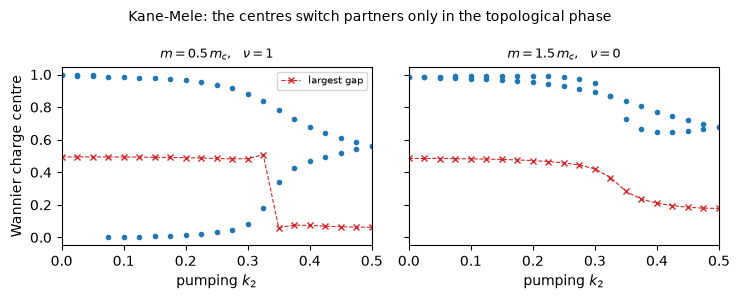

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.0), sharey=True)
for ax, (factor, flow) in zip(axes, sorted(flows.items())):
    ax.plot(flow.pump, flow.centers_fractional, "o", ms=3, color="C0")
    ax.plot(flow.pump, (flow.gap_center / (2 * np.pi)) % 1.0, "x--", ms=4, lw=0.8,
            color="C3", label="largest gap")
    ax.set_title(r"$m = %g\,m_c$,   $\nu = %d$" % (factor, flow.z2), fontsize=9)
    ax.set_xlabel("pumping $k_2$")
    ax.set_xlim(0.0, 0.5)
axes[0].set_ylabel("Wannier charge centre")
axes[0].legend(fontsize=7)
fig.suptitle("Kane-Mele: the centres switch partners only in the topological phase",
             fontsize=10)
fig.tight_layout()

## Bismuthene, and what to do when the two routes disagree

A real $\mathbb{Z}_2$ insulator is a spinor calculation with a fully relativistic dataset,
and the honeycomb bismuth layer of notebook 08 is one. On a crystal the call is
`get_z2(method=...)` for a plane and `get_z2_3d()` for the four indices of a
three-dimensional cell; this one is quoted rather than run, because it peaks at 7.8 GB:

```
SCF, 7 irreducible k-points          -295.610317532 Ry     281 s
parity, 4 TRIM: nu = 0                delta = -1 at all four     133 s
Wilson, 12 x 7 mesh: z2 = 1           gap_step = 0.197           786 s
```

The two routes disagree, which is the interesting outcome rather than an embarrassing one.
Fu and Kane's route reads the invariant off the parity eigenvalues at the time-reversal
invariant momenta: four diagonalisations at exact points, no mesh at all, and the parities
came out $\pm1$ to 1e-6. The Wilson route has a mesh, and its own diagnostic says that mesh
is too coarse, the reference line moving a fifth of the way round the circle in a single
pumping step. Where they disagree like this, the parity answer is the one to take.

## What it refuses

The Kubo map runs on **norm-conserving** datasets only: the $\varepsilon_n\,\partial_k S$
term is identically zero without an augmentation charge, so nothing validated here can say
whether its convention is right, and it is refused rather than guessed. The lattice flux
carries the augmentation charge correctly and runs on all three kinds of dataset. A
$\mathbb{Z}_2$ needs `noncolin = .true.` and asks for it by name: without spin-orbit
coupling the bands are spin degenerate, the two copies wind oppositely, and the invariant
is zero for a reason that has nothing to do with the band structure. And a **per-band**
curvature is meaningful only for a non-degenerate band, since inside a degenerate multiplet
only the sum over the members is defined.

---
The tests behind this notebook: `tests/regression/test_topology.py`, which runs silicon's
parity product over the eight TRIM and its vanishing curvature on all three kinds of
dataset; `tests/unit/test_topology_curvature.py`, which holds the Haldane mesh sweep, the
gauge invariance of a plaquette and the agreement of the two routes on the integral; and
`tests/unit/test_topology_mesh.py`, which holds the zone-edge wrap -- the step from
$k = 0.4$ to $k = -0.5$ being the same as the step to $k = 0.5$ only once the Miller
indices are shifted with it.